# Import the necessary libraries and modules

In [23]:
import torch  # PyTorch library for deep learning
import torch.nn as nn  # Neural network modules
import numpy as np  # NumPy library for numerical computations
import pennylane as qml  # PennyLane for quantum machine learning
import matplotlib.pyplot as plt  # Matplotlib for plotting
from matplotlib.ticker import ScalarFormatter # Formatter for scientific notation in plots
dtype = torch.float  # Set default tensor data type to float

In [24]:
def Solution1(r, params):
    M = params[0]
    return -(1 - (2*M)/r)

def Solution2(r, params):
    M = params[0]
    return (1 - (2*M)/r)**-1

def test_PINN(NN, domain, params, num_test):
    r = torch.linspace(domain[0], domain[1], num_test).view(-1, 1)
    with torch.no_grad():
        alpha_pred, beta_pred = NN(r)


    g00_pred, g11_pred = -torch.exp(2*alpha_pred), torch.exp(2*beta_pred)
    g00_exact, g11_exact = Solution1(r, params), Solution2(r, params)

    residual_g00_error = g00_pred - g00_exact
    residual_g11_error = g11_pred - g11_exact
    
    l2_error_g00 = (g00_exact - g00_pred)**2
    l2_metric_g00 = torch.mean(l2_error_g00)

    l2_error_g11 = (g11_exact - g11_pred)**2
    l2_metric_g11 = torch.mean(l2_error_g11)
    
    
    abs_error_g00 = torch.abs(g00_exact - g00_pred)
    MAE_g00 = torch.mean(abs_error_g00)

    percent_MAE_g00 = MAE_g00*100
    
    abs_error_g11 = torch.abs(g11_exact - g11_pred)
    MAE_g11 = torch.mean(abs_error_g11)
    percent_MAE_g11 = MAE_g11*100
    return r,g00_pred, g11_pred, residual_g00_error, residual_g11_error, l2_error_g00, l2_error_g11, l2_metric_g00, l2_metric_g11, MAE_g00, percent_MAE_g00, MAE_g11, percent_MAE_g11

In [25]:
# Set the necessary parameters
M = 15
params = [M]
num_test = 500
domain = [100, 300]
seed = 42

# Classical Neural Network

In [26]:
classic_model_list = []
classic_history_lists = []

def init_weights(m):
    """
    Initializes weights and biases for a linear layer.

    Args:
        m (nn.Linear): The linear layer to initialize.

    Notes:
        - Applies uniform weight initialization within the range [-n0, n0].
        - Initializes biases with a constant value of 0.01.
    """
    if isinstance(m, nn.Linear):
        out_sz = torch.tensor(m.out_features)
        n0 = 1.0/torch.sqrt(out_sz)
        m.weight.data.uniform_(-n0, n0)
        m.bias.data.fill_(0.01)

class CNeuralNet(nn.Module):
    """
    Classical neural network class.

    Args:
        input_size (int): Size of the input features.
        hidden_size (int): Number of hidden units in the neural network.
        output_size (int): Size of the output.

    Attributes:
        fnn (nn.Sequential): Feedforward neural network with six linear layer followed by a LogSigmoid activation.

    Notes:
        - The classical neural network architecture consists of six hidden layers.
        - The input layer has 'input_size' neurons.
        - The output layer has 'output_size' neurons.
    """
    def __init__(self, input_size, hidden_size, output_size):
        super(CNeuralNet, self).__init__()

        self.fnn = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.LogSigmoid(),
            nn.Linear(hidden_size, hidden_size),
            nn.LogSigmoid(),
            nn.Linear(hidden_size, hidden_size),
            nn.LogSigmoid(),
            nn.Linear(hidden_size, hidden_size),
            nn.LogSigmoid(),
            nn.Linear(hidden_size, hidden_size),
            nn.LogSigmoid(),
            nn.Linear(hidden_size, hidden_size),
            nn.LogSigmoid(),
            nn.Linear(hidden_size, output_size),
        )

        # self.fnn.apply(init_weights)

    def forward(self, x):
        out = self.fnn(x)
        a = out[:, 0].view(-1, 1)
        b = out[:, 1].view(-1, 1)
        return a, b
    
for idx, hs in enumerate([10, 30, 50]):
    idx = idx + 1
    input_size , hidden_size, output_size = 1, hs, 2
    model_classic = CNeuralNet(input_size, hidden_size, output_size)
    model_classic.load_state_dict(torch.load(f"..\\trained_models\\classical einstein field equations\\{seed}\\Classical model_{seed}_{hs}.pth"))
    classic_model_list.append(model_classic)
    classic_history_lists.append(torch.load(f"..\\trained_models\\classical einstein field equations\\{seed}\\loss_Classical model_{seed}_{hs}.pt"))

In [27]:
# Unpack the classical models and their corresponding training histories
cmodel1, cmodel2, cmodel3 = classic_model_list
c_hist1, c_hist2, c_hist3 = classic_history_lists

In [28]:
# Extract the minimum training loss for each classical model and store it in a list
cmin_loss_list = []
for idx in range(len(classic_model_list)):
    cmin_loss_list.append(min(classic_history_lists[idx][0]))

In [29]:
# Evaluate each classical model on the test dataset and store performance metrics
cl2_error_g00_list = []
cl2_metric_g00_list = []
cpred_g00_list = []
cMAE_g00_list = []
cpercent_g00_MAE = []
cresidual_g00_error_list = []


cl2_error_g11_list = []
cl2_metric_g11_list = []
cpred_g11_list = []
cMAE_g11_list = []
cpercent_g11_MAE = []
cresidual_g11_error_list = []

for idx in range(len(classic_model_list)):
    print(100*"=")
    print(f"case{idx+1}:\n")
    r,g00_pred, g11_pred, residual_g00_error, residual_g11_error, l2_error_g00, l2_error_g11, l2_metric_g00, l2_metric_g11, MAE_g00, percent_MAE_g00, MAE_g11, percent_MAE_g11 = test_PINN(classic_model_list[idx], domain, params, num_test)
    cresidual_g00_error_list.append(residual_g00_error)
    cl2_error_g00_list.append(l2_error_g00)
    cl2_metric_g00_list.append(l2_metric_g00)
    cpred_g00_list.append(g00_pred)
    cMAE_g00_list.append(MAE_g00)
    cpercent_g00_MAE.append(percent_MAE_g00)

    cresidual_g11_error_list.append(residual_g11_error)
    cl2_error_g11_list.append(l2_error_g11)
    cl2_metric_g11_list.append(l2_metric_g11)
    cpred_g11_list.append(g11_pred)
    cMAE_g11_list.append(MAE_g11)
    cpercent_g11_MAE.append(percent_MAE_g11)

case1:

case2:

case3:



# Quantum Neural Network

In [30]:
quantum_model_list = []
quantum_history_lists = []
# Set the number of qubits to 3
n_qubits = 2
# Create a quantum device with 3 qubits
dev = qml.device("default.qubit", wires=n_qubits)

def RY_layer(w):
    """
    Apply a layer of single-qubit rotations around the Y-axis (RY gates).

    Args:
        w (list): List of rotation angles for each qubit.
    """
    for idx, element in enumerate(w):
        qml.RY(element, wires=idx)

@qml.qnode(dev)
def quantum_net(input_features, n_qubits, ansatz_depth, feature_weights, ansatz_weights, out_weights):
    """
    Quantum circuit

    Args:
        input_features: Input features.
        n_qubits (int): Number of qubits in the circuit.
        ansatz_depth (int): Depth of the ansatz (number of layers).
        feature_weights (torch.Tensor): List of parameters.
        ansatz_weights (torch.Tensor): List of parameters.
        out_weights (torch.Tensor): List of parameters.

    Returns:
        tuple: Tuple of expectation values for Pauli-Z operators on qubits 0 and 1 as g00 and g11.
    """
    # apply feature map layers
    temp1 = feature_weights[0]*(input_features[0]**feature_weights[1])
    temp2 = feature_weights[2]*(input_features[0]**feature_weights[3])
    qml.RY(temp1, wires=0)
    qml.RY(temp2, wires=1)
    qml.CNOT(wires=[0,1])

    # apply ansatz layers
    for k in range(ansatz_depth):
        RY_layer(ansatz_weights[k])
        qml.CNOT(wires=[0,1])

    # Compute expectation values for Pauli-Z operators
    exp_vals = [qml.expval(out_weights[0]*qml.PauliZ(0)), qml.expval(out_weights[1]*qml.PauliZ(1))]
    return tuple(exp_vals)


class QNeuralNet(nn.Module):
    """
    quantum neural network class.

    Args:
        n_qubits (int): Number of qubits in the circuit.
        feature_depth (int): Depth of the feature map (number of layers).
        ansatz_depth (int): Depth of the ansatz (number of layers).

    Notes:
        - The quantum neural network architecture consists of two qubits.
        - The feature map has 'feature_depth' layers.
        - The ansatz has 'ansatz_depgh' layers.
    """
    def __init__(self, n_qubits, feature_depth, ansatz_depth):
        super(QNeuralNet, self).__init__()
        
        # Set the number qubits, number of ansatz layer and feature map layers
        self.n_qubits = n_qubits
        self.ansatz_depth = ansatz_depth
        self.feature_depth = feature_depth
        
        # Initialize parameters of quantum circuit
        self.feature_weights = nn.Parameter(0.1*torch.randn((2*n_qubits*feature_depth)).view(-1, 1))
        self.ansatz_weights = nn.Parameter(torch.randn(ansatz_depth*n_qubits).view(ansatz_depth, n_qubits))
        self.out_weights = nn.Parameter(torch.FloatTensor(2).uniform_(-1, 1))

    def forward(self, x):
        """
        Forward pass through the neural network.

        Args:
            x (torch.Tensor): Input data.

        Returns:
            torch.Tensor: Outputs predictions from the neural network.
        """
        # Scale features by dividing by 100
        x = x/100
        # Initialize an empty tensor for quantum output
        q_out = torch.Tensor(0, 2)

        for elem in x:
            # Apply the quantum circuit (quantum_net) to each input element
            q_out_elem = torch.hstack(tuple(quantum_net(elem, self.n_qubits, self.ansatz_depth, self.feature_weights,self.ansatz_weights, self.out_weights))).float().unsqueeze(0)
            q_out = torch.cat((q_out, q_out_elem)) # Concatenate quantum outputs

        # Compute the ansatz solution by applying the arcsine function to the neural network outputs
        out1 = torch.arcsin(q_out[:, 0]).view(-1, 1)
        out2 = torch.arcsin(q_out[:, 1]).view(-1, 1)
        
        return out1, out2
    
for idx, layer in enumerate([1, 2, 3]):
    idx = idx + 1
    feature_depth, ansatz_depth = 1, layer
    model_quantum = QNeuralNet(n_qubits, feature_depth, ansatz_depth)
    model_quantum.load_state_dict(torch.load(f"..\\trained_models\\quantum einstein field equations\\{seed}\\quantum model_{seed}_{layer}.pth"))
    quantum_model_list.append(model_quantum)
    quantum_history_lists.append(torch.load(f"..\\trained_models\\quantum einstein field equations\\{seed}\\loss_quantum model_{seed}_{layer}.pt"))

In [31]:
# Unpack quantum models and their corresponding training histories
qmodel1, qmodel2, qmodel3 = quantum_model_list
q_hist1, q_hist2, q_hist3 = quantum_history_lists

In [32]:
# Extract the minimum training loss for each quantum model and store in a list
qmin_loss_list = []
for idx in range(len(quantum_model_list)):
    qmin_loss_list.append(min(quantum_history_lists[idx][0]))

In [33]:
# Evaluate each quantum model on the test dataset and collect performance metrics
ql2_error_g00_list = []
ql2_metric_g00_list = []
qpred_g00_list = []
qMAE_g00_list = []
qpercent_g00_MAE = []
qresidual_g00_error_list = []


ql2_error_g11_list = []
ql2_metric_g11_list = []
qpred_g11_list = []
qMAE_g11_list = []
qpercent_g11_MAE = []
qresidual_g11_error_list = []

for idx in range(len(quantum_model_list)):
    print(100*"=")
    print(f"case{idx+1}:\n")
    r,g00_pred, g11_pred, residual_g00_error, residual_g11_error, l2_error_g00, l2_error_g11, l2_metric_g00, l2_metric_g11, MAE_g00, percent_MAE_g00, MAE_g11, percent_MAE_g11 = test_PINN(quantum_model_list[idx], domain, params, num_test)
    qresidual_g00_error_list.append(residual_g00_error)
    ql2_error_g00_list.append(l2_error_g00)
    ql2_metric_g00_list.append(l2_metric_g00)
    qpred_g00_list.append(g00_pred)
    qMAE_g00_list.append(MAE_g00)
    qpercent_g00_MAE.append(percent_MAE_g00)

    qresidual_g11_error_list.append(residual_g11_error)
    ql2_error_g11_list.append(l2_error_g11)
    ql2_metric_g11_list.append(l2_metric_g11)
    qpred_g11_list.append(g11_pred)
    qMAE_g11_list.append(MAE_g11)
    qpercent_g11_MAE.append(percent_MAE_g11)

case1:

case2:

case3:



# Hybrid Quantum Neural Network

In [34]:
hybrid_model_list = []
hybrid_history_lists = []
# Set the number of qubits to 3
n_qubits = 3
# Create a quantum device with 3 qubits
dev = qml.device("default.qubit", wires=n_qubits)

def RY_layer(w):
    """
    Apply a layer of single-qubit rotations around the Y-axis (RY gates).

    Args:
        w (list): List of rotation angles for each qubit.
    """
    for idx, element in enumerate(w):
        qml.RY(element, wires=idx)

def entangling_layer(nqubits):
    """
    Apply an entangling layer of CNOT gates to adjacent qubits.

    Args:
        nqubits (int): Number of qubits in use.
    """
    for i in range(0, nqubits - 1):
        qml.CNOT(wires=[i, i + 1])

def init_weights(m):
    """
    Initializes weights and biases for a linear layer.

    Args:
        m (nn.Linear): The linear layer to initialize.

    Notes:
        - Applies uniform weight initialization within the range [-n0, n0].
        - Initializes biases with a constant value of 0.01.
    """
    if isinstance(m, nn.Linear):
        out_sz = torch.tensor(m.out_features)
        n0 = 1.0/torch.sqrt(out_sz)
        m.weight.data.uniform_(-n0, n0)
        # m.bias.data.fill_(0.01)

@qml.qnode(dev)
def hquantum_net(input_features, n_qubits, q_depth, q_weights):
    """
    Quantum circuit as a part of quantum hybrid neural network

    Args:
        input_features (torch.Tensor): Input features.
        n_qubits (int): Number of qubits in the circuit.
        q_depth (int): Number of quantum layers.
        q_weights (torch.Tensor): List of parameters.
    Returns:
        tuple: Tuple of expectation values for Pauli-Z operators on qubits 0, 1, and 2.
    """
    RY_layer(input_features[0])
    entangling_layer(n_qubits)
    
    RY_layer(input_features[1])
    RY_layer(q_weights[0])
    entangling_layer(n_qubits)
    
    RY_layer(input_features[2])
    RY_layer(q_weights[1])
    entangling_layer(n_qubits)
    
    RY_layer(input_features[3])
    RY_layer(q_weights[2])
    entangling_layer(n_qubits)

    exp_vals = [qml.expval(qml.PauliZ(position)) for position in range(0, n_qubits)]
    return tuple(exp_vals)

class HQNeuralNet(nn.Module):
    """
    quantum hybrid neural network class.

    Args:
        input_size (int): Size of the input features.
        hidden_size (int): Number of hidden units in the neural network.
        n_qubits (int): Number of qubits in the circuit.
        q_depth (int): Number of quantum layers.
        output_size (int): Size of the output.

    Attributes:
        fnn (nn.Sequential): Feedforward neural network with a linear layer followed by a Tanh activation.

    Notes:
        - The first classical neural network architecture consists of one hidden layer.
        - The input layer has 'input_size' neurons.
        - The hidden layers has 'hidden_size' neurons with a Tanh activation.
        - The quantum neural network architecture consists of 'n_qubits' and 'q_depth ' layers.
        - The second classical neural network architecture consists of one linear layer.
        - The output layer has 'output_size' neurons.
    """
    def __init__(self, input_size, hidden_size, n_qubits, q_depth, output_size):
        super().__init__()
        
        # Define the feedforward neural network (fnn)
        self.fnn = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.LogSigmoid(),
            nn.Linear(hidden_size, hidden_size),
            nn.LogSigmoid(),
            nn.Linear(hidden_size, hidden_size),
            nn.LogSigmoid(),
            nn.Linear(hidden_size, hidden_size),
            nn.LogSigmoid(),
            nn.Linear(hidden_size, (q_depth+1)*n_qubits),
        )
        # self.fnn.apply(init_weights)

        #Define the feedforward (n_qubits, output_size) layer as a output layer
        self.output_layer = nn.Linear(n_qubits, output_size)
        # self.output_layer.apply(init_weights)

        # Set the number qubits, number of quantum layers
        self.n_qubits = n_qubits
        self.q_depth = q_depth
        
        # Initialize parameters of quantum circuit
        self.q_weights = nn.Parameter(0.2*torch.randn(q_depth * n_qubits).view(q_depth, n_qubits))

    def forward(self, x):
        """
        Forward pass through the neural network.

        Args:
            data (torch.Tensor): Input data.

        Returns:
            torch.Tensor: Outputs predictions from the neural network.
        """
        # Pass the data through the feedforward neural network (self.fnn)
        out = self.fnn(x)
        # Initialize an empty tensor for quantum output
        q_out = torch.Tensor(0, self.n_qubits)

        for elem in out:
            # Apply the quantum circuit (hquantum_net) to each output element
            elem = elem.view((self.q_depth+1), self.n_qubits)
            q_out_elem = torch.hstack(tuple(hquantum_net(elem, self.n_qubits, self.q_depth, self.q_weights))).float().unsqueeze(0)
            q_out = torch.cat((q_out, q_out_elem))

        # Pass the output of quantum circuit through the feedforward linear layer
        out = self.output_layer(q_out)
        a = out[:, 0].view(-1, 1)
        b = out[:, 1].view(-1, 1)
        return a, b
for idx, hs in enumerate([10, 30, 50]):
    idx = idx + 1
    input_size, hidden_size, q_depth, output_size = 1, hs, 3, 2
    model_hybrid = HQNeuralNet(input_size, hidden_size, n_qubits, q_depth, output_size)
    model_hybrid.load_state_dict(torch.load(f"..\\trained_models\\hybrid einstein field equations\\{seed}\\hybrid model_{seed}_{hs}.pth"))
    hybrid_model_list.append(model_hybrid)
    hybrid_history_lists.append(torch.load(f"..\\trained_models\\hybrid einstein field equations\\{seed}\\loss_hybrid model_{seed}_{hs}.pt"))

In [35]:
# Unpack hybrid quantum-classical models and their corresponding training histories
hmodel1, hmodel2, hmodel3 = hybrid_model_list
h_hist1, h_hist2, h_hist3 = hybrid_history_lists

In [36]:
# Extract the minimum training loss for each hybrid model and store in a list
hmin_loss_list = []
for idx in range(len(hybrid_model_list)):
    hmin_loss_list.append(min(hybrid_history_lists[idx][0]))

In [37]:
# Evaluate each hybrid model on the test dataset and collect performance metrics
hl2_error_g00_list = []
hl2_metric_g00_list = []
hpred_g00_list = []
hMAE_g00_list = []
hpercent_g00_MAE = []
hresidual_g00_error_list = []


hl2_error_g11_list = []
hl2_metric_g11_list = []
hpred_g11_list = []
hMAE_g11_list = []
hpercent_g11_MAE = []
hresidual_g11_error_list = []

for idx in range(len(hybrid_model_list)):
    print(100*"=")
    print(f"case{idx+1}:\n")
    r, g00_pred, g11_pred, residual_g00_error, residual_g11_error, l2_error_g00, l2_error_g11, l2_metric_g00, l2_metric_g11, MAE_g00, percent_MAE_g00, MAE_g11, percent_MAE_g11 = test_PINN(hybrid_model_list[idx], domain, params, num_test)
    hresidual_g00_error_list.append(residual_g00_error)
    hl2_error_g00_list.append(l2_error_g00)
    hl2_metric_g00_list.append(l2_metric_g00)
    hpred_g00_list.append(g00_pred)
    hMAE_g00_list.append(MAE_g00)
    hpercent_g00_MAE.append(percent_MAE_g00)

    hresidual_g11_error_list.append(residual_g11_error)
    hl2_error_g11_list.append(l2_error_g11)
    hl2_metric_g11_list.append(l2_metric_g11)
    hpred_g11_list.append(g11_pred)
    hMAE_g11_list.append(MAE_g11)
    hpercent_g11_MAE.append(percent_MAE_g11)

case1:

case2:

case3:



# compare three nets

In [38]:
# Print summary of classical neural network performance for each hidden size
print(">>Classic neural network<<")
for idx, hs in enumerate([10, 30, 50]):
    g00 = cl2_metric_g00_list[idx].item()
    g11 = cl2_metric_g11_list[idx].item()
    total = g00 + g11
    print(f"hidden_size: {hs} | minimum of loss function = {cmin_loss_list[idx]}")
    print(f"component g00    | MSE = {g00}")
    print(f"component g11    | MSE = {g11}")
    print(f"g00 + g11        | MSE = {total}")
    print("\n")

>>Classic neural network<<
hidden_size: 10 | minimum of loss function = 0.00014271537656895816
component g00    | MSE = 2.430055928925867e-06
component g11    | MSE = 1.35073477736114e-07
g00 + g11        | MSE = 2.565129406661981e-06


hidden_size: 30 | minimum of loss function = 0.00025794332032091916
component g00    | MSE = 8.467790735267045e-07
component g11    | MSE = 2.27833788812859e-06
g00 + g11        | MSE = 3.1251169616552943e-06


hidden_size: 50 | minimum of loss function = 0.00031751085771247745
component g00    | MSE = 3.380988005119434e-07
component g11    | MSE = 2.3631807835045038e-06
g00 + g11        | MSE = 2.701279584016447e-06




In [39]:
# Print summary of quantum neural network performance for each number of layers
print(">>Quantum neural network<<")
for idx, hs in enumerate([1, 2, 3]):
    g00 = ql2_metric_g00_list[idx].item()
    g11 = ql2_metric_g11_list[idx].item()
    total = g00 + g11
    print(f"number of layers: {hs} | minimum of loss function = {qmin_loss_list[idx]}")
    print(f"component g00     | MSE = {g00}")
    print(f"component g11     | MSE = {g11}")
    print(f"g00 + g11         | MSE = {total}")
    print("\n")

>>Quantum neural network<<
number of layers: 1 | minimum of loss function = 0.0005680788308382034
component g00     | MSE = 8.266621875918645e-07
component g11     | MSE = 6.64633626001887e-06
g00 + g11         | MSE = 7.472998447610735e-06


number of layers: 2 | minimum of loss function = 0.0004337032441981137
component g00     | MSE = 3.4226206935272785e-06
component g11     | MSE = 1.2689999948634068e-06
g00 + g11         | MSE = 4.691620688390685e-06


number of layers: 3 | minimum of loss function = 0.0005856544012203813
component g00     | MSE = 6.812820629420457e-06
component g11     | MSE = 6.7251639848109335e-06
g00 + g11         | MSE = 1.3537984614231391e-05




In [40]:
# Print summary of hybrid neural network performance for each hidden size
print(">>Hybrid neural network<<")
for idx, hs in enumerate([10, 30, 50]):
    g00 = hl2_metric_g00_list[idx].item()
    g11 = hl2_metric_g11_list[idx].item()
    total = g00 + g11
    print(f"hidden_size: {hs} | minimum of loss function = {hmin_loss_list[idx]}")
    print(f"component g00     | MSE = {g00}")
    print(f"component g11     | MSE = {g11}")
    print(f"g00 + g11         | MSE = {total}")
    print("\n")

>>Hybrid neural network<<
hidden_size: 10 | minimum of loss function = 0.00026319007156416774
component g00     | MSE = 4.999582188247587e-07
component g11     | MSE = 4.7396476077210536e-08
g00 + g11         | MSE = 5.473546949019692e-07


hidden_size: 30 | minimum of loss function = 0.0006920929881744087
component g00     | MSE = 5.96200197833241e-06
component g11     | MSE = 1.2917203093820717e-05
g00 + g11         | MSE = 1.8879205072153127e-05


hidden_size: 50 | minimum of loss function = 0.00027414062060415745
component g00     | MSE = 2.639899605583196e-07
component g11     | MSE = 1.2720796576104476e-06
g00 + g11         | MSE = 1.5360696181687672e-06




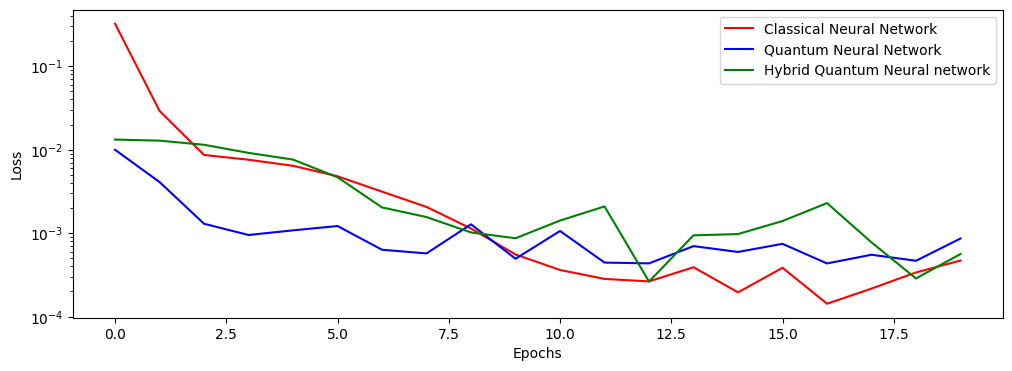

In [41]:
# Plot loss function versus epochs on a semilogarithmic scale for classical, quantum, and hybrid neural networks
fig1, ax1 = plt.subplots(1, 1, figsize=(12, 4))
ax1.semilogy(c_hist1[0], label="Classical Neural Network", color="r")
ax1.semilogy(q_hist2[0], label="Quantum Neural Network", color="b")
ax1.semilogy(h_hist1[0], label="Hybrid Quantum Neural network", color="green")
ax1.legend(loc='upper right')
ax1.set(xlabel="Epochs", ylabel="Loss")
plt.show()

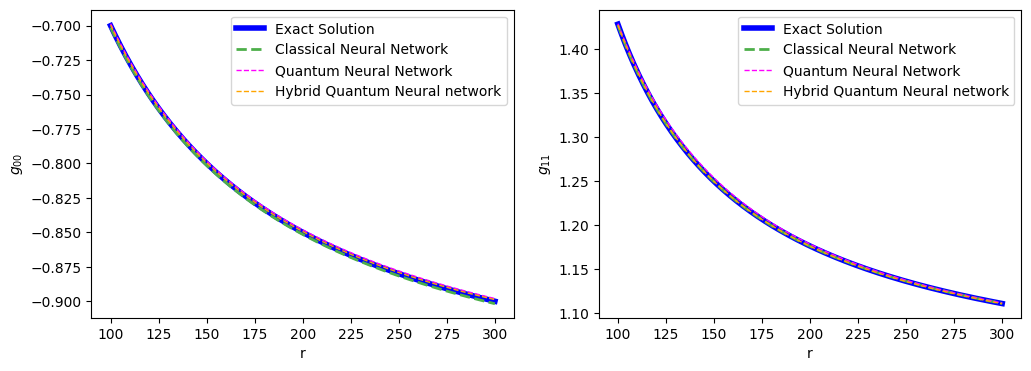

In [42]:
# Plot predicted solutions from classical, quantum, and hybrid neural networks alongside the exact solution
exact_solution1 = Solution1(r, params)
exact_solution2 = Solution2(r, params)

fig2, ax2 = plt.subplots(1, 2, figsize=(12, 4))
ax2[0].plot(r.cpu(), exact_solution1.cpu().detach().numpy(), label="Exact Solution", color="blue", linewidth=4)
ax2[0].plot(r.cpu(), cpred_g00_list[0].cpu().detach().numpy(), label="Classical Neural Network",color="#4daf4a", linestyle='dashed', linewidth=2)
ax2[0].plot(r.cpu(), qpred_g00_list[1].cpu().detach().numpy(), label="Quantum Neural Network",color="magenta", linestyle='dashed', linewidth=1)
ax2[0].plot(r.cpu(), hpred_g00_list[0].cpu().detach().numpy(), label="Hybrid Quantum Neural network",color="orange", linestyle='dashed', linewidth=1)
ax2[0].set(xlabel="r", ylabel="$g_{00}$")
ax2[0].legend()

ax2[1].plot(r.cpu(), exact_solution2.cpu().detach().numpy(), label="Exact Solution", color="blue", linewidth=4)
ax2[1].plot(r.cpu(), cpred_g11_list[0].cpu().detach().numpy(), label="Classical Neural Network",color="#4daf4a", linestyle='dashed', linewidth=2)
ax2[1].plot(r.cpu(), qpred_g11_list[2].cpu().detach().numpy(), label="Quantum Neural Network",color="magenta", linestyle='dashed', linewidth=1)
ax2[1].plot(r.cpu(), hpred_g11_list[0].cpu().detach().numpy(), label="Hybrid Quantum Neural network",color="orange", linestyle='dashed', linewidth=1)
ax2[1].set(xlabel="r", ylabel="$g_{11}$")
ax2[1].legend()
plt.show()

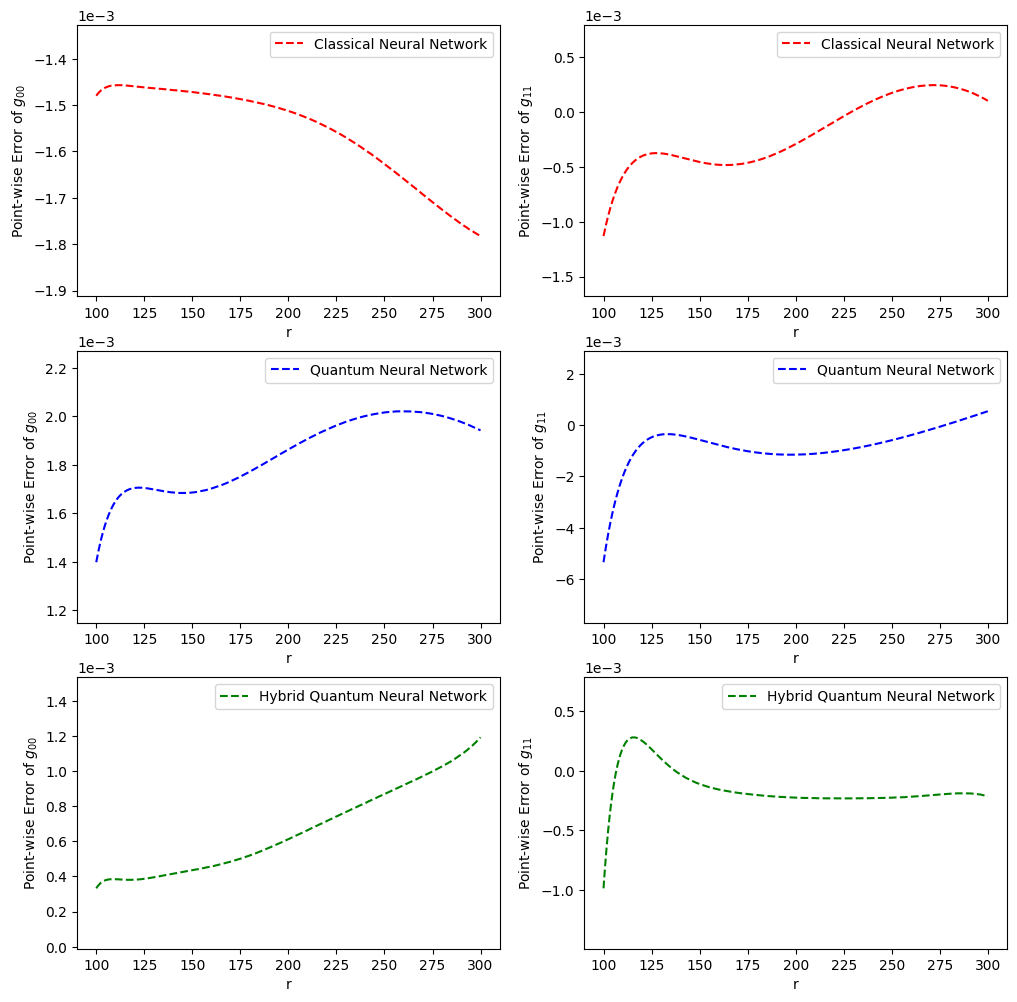

In [43]:
# Plot point-wise error for classical, quantum, and hybrid neural networks across the domain
fig, axs = plt.subplots(3, 2, figsize=(12, 12))

# Helper function to compute buffered ylim
def buffered_ylim(data, buffer_ratio=0.4):
    y = data.detach().numpy()
    ymin, ymax = np.min(y), np.max(y)
    buffer = buffer_ratio * (ymax - ymin) if ymax != ymin else 1e-6
    return ymin - buffer, ymax + buffer

# Classical
axs[0][0].plot(r.cpu(), cresidual_g00_error_list[0].detach().numpy(), linestyle="dashed", color="r", label='Classical Neural Network')
axs[0][0].set_ylim(*buffered_ylim(cresidual_g00_error_list[0]))
axs[0][0].set_xlabel('r')
axs[0][0].set_ylabel('Point-wise Error of $g_{00}$')
axs[0][0].legend(loc='upper right')
axs[0][0].yaxis.set_major_formatter(ScalarFormatter(useMathText=False))
axs[0][0].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

axs[0][1].plot(r.cpu(), cresidual_g11_error_list[0].detach().numpy(), linestyle="dashed", color="r", label='Classical Neural Network')
axs[0][1].set_ylim(*buffered_ylim(cresidual_g11_error_list[0]))
axs[0][1].set_xlabel('r')
axs[0][1].set_ylabel('Point-wise Error of $g_{11}$')
axs[0][1].legend(loc='upper right')
axs[0][1].yaxis.set_major_formatter(ScalarFormatter(useMathText=False))
axs[0][1].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

# Quantum
axs[1][0].plot(r.cpu(), qresidual_g00_error_list[1].detach().numpy(), linestyle="dashed", color="b", label='Quantum Neural Network')
axs[1][0].set_ylim(*buffered_ylim(qresidual_g00_error_list[1]))
axs[1][0].set_xlabel('r')
axs[1][0].set_ylabel('Point-wise Error of $g_{00}$')
axs[1][0].legend(loc='upper right')
axs[1][0].yaxis.set_major_formatter(ScalarFormatter(useMathText=False))
axs[1][0].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

axs[1][1].plot(r.cpu(), qresidual_g11_error_list[1].detach().numpy(), linestyle="dashed", color="b", label='Quantum Neural Network')
axs[1][1].set_ylim(*buffered_ylim(qresidual_g11_error_list[1]))
axs[1][1].set_xlabel('r')
axs[1][1].set_ylabel('Point-wise Error of $g_{11}$')
axs[1][1].legend(loc='upper right')
axs[1][1].yaxis.set_major_formatter(ScalarFormatter(useMathText=False))
axs[1][1].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

# Hybrid
axs[2][0].plot(r.cpu(), hresidual_g00_error_list[0].detach().numpy(), linestyle="dashed", color="green", label='Hybrid Quantum Neural Network')
axs[2][0].set_ylim(*buffered_ylim(hresidual_g00_error_list[0]))
axs[2][0].set_xlabel('r')
axs[2][0].set_ylabel('Point-wise Error of $g_{00}$')
axs[2][0].legend(loc='upper right')
axs[2][0].yaxis.set_major_formatter(ScalarFormatter(useMathText=False))
axs[2][0].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

axs[2][1].plot(r.cpu(), hresidual_g11_error_list[0].detach().numpy(), linestyle="dashed", color="green", label='Hybrid Quantum Neural Network')
axs[2][1].set_ylim(*buffered_ylim(hresidual_g11_error_list[0]))
axs[2][1].set_xlabel('r')
axs[2][1].set_ylabel('Point-wise Error of $g_{11}$')
axs[2][1].legend(loc='upper right')
axs[2][1].yaxis.set_major_formatter(ScalarFormatter(useMathText=False))
axs[2][1].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
plt.show()


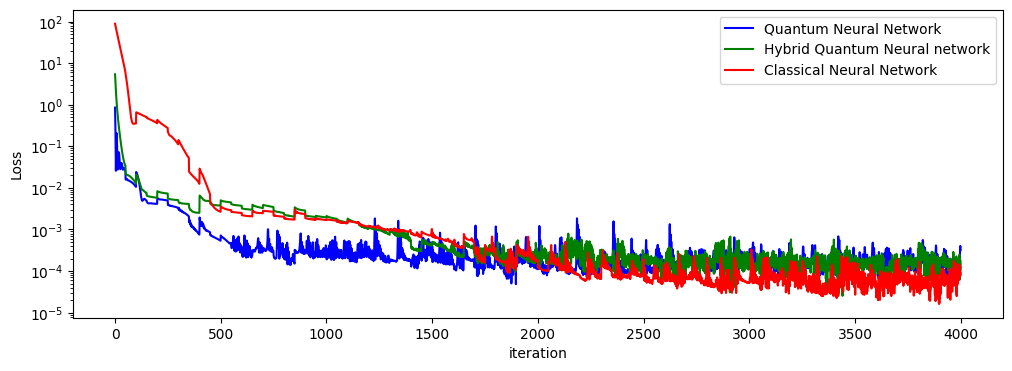

In [44]:
# Plot loss function versus iteration on a semilogarithmic scale for classical, quantum, and hybrid neural networks
fig1, ax1 = plt.subplots(1, 1, figsize=(12, 4))
ax1.semilogy(q_hist2[6], label="Quantum Neural Network", color="b")
ax1.semilogy(h_hist1[6], label="Hybrid Quantum Neural network", color="green")
ax1.semilogy(c_hist1[6], label="Classical Neural Network", color="r")
ax1.legend(loc='upper right')
ax1.set(xlabel="iteration", ylabel="Loss")
plt.show()